In [2]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [117]:
df_US = df[df['job_country'] == 'United States'].copy()
df_US = df_US.explode('job_skills')
df_US = df_US.dropna(subset='job_skills')

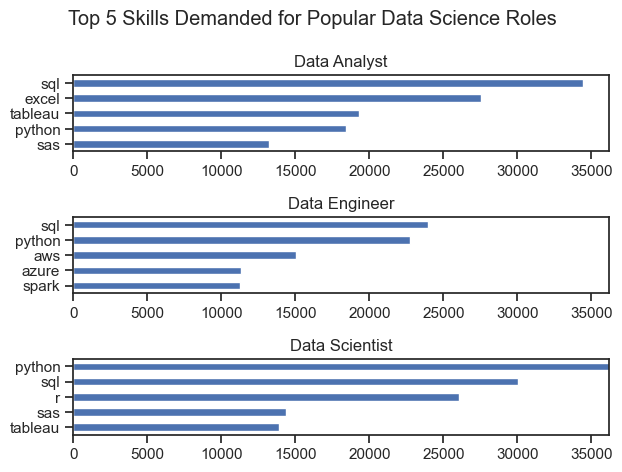

In [123]:
df_US_group = df_US.groupby(['job_title_short', 'job_skills']).size().reset_index(name='count').sort_values(by='count', ascending=False)
job_titles = df_US['job_title_short'].value_counts().head(3).sort_values()
job_titles = job_titles.index.to_list()

df_US_group[df_US_group['job_title_short'].isin(job_titles)]


fig,ax = plt.subplots(3,1)
for i,job_title in enumerate(job_titles):
    df_plot = df_US_group[df_US_group['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', y=
                 'count', x='job_skills', ax=ax[i], legend=False)
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    if i > 0:
        ax[i].set_xlim(ax[0].get_xlim())
    else:
        pass
plt.suptitle('Top 5 Skills Demanded for Popular Data Science Roles')
plt.tight_layout()

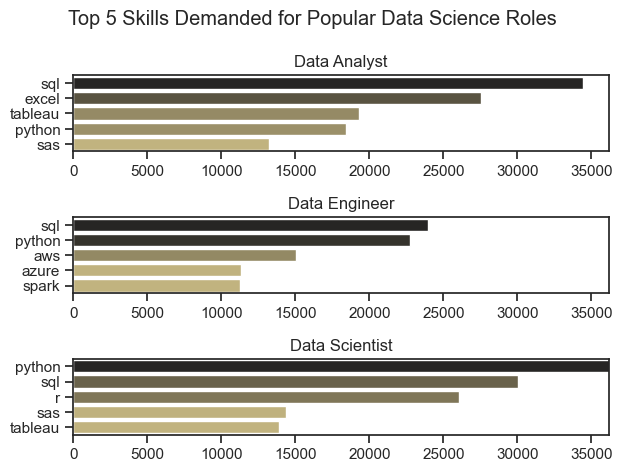

In [124]:
#improve the plot using seaborn
sns.set_theme(style='ticks')
fig,ax = plt.subplots(3,1)
for i,job_title in enumerate(job_titles):
    df_plot = df_US_group[df_US_group['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='count', y='job_skills', ax=ax[i], hue='count', palette='dark:y_r' ,legend=False)
    #df_plot.plot(kind='barh', y='count', x='job_skills', ax=ax[i], legend=False)
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    if i > 0:
        ax[i].set_xlim(ax[0].get_xlim())
    else:
        pass
plt.suptitle('Top 5 Skills Demanded for Popular Data Science Roles')
plt.tight_layout()

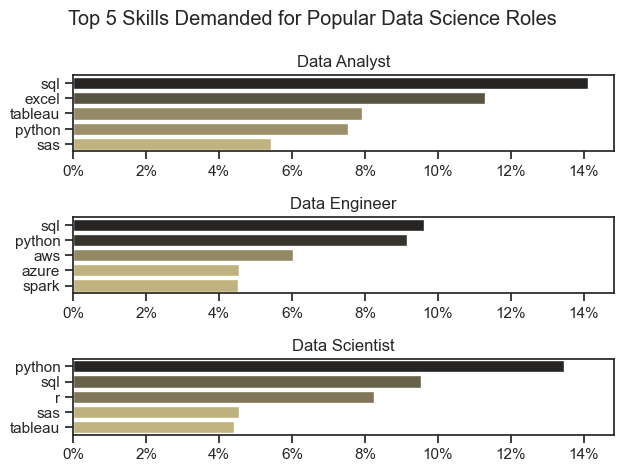

In [125]:
#use percentage instead of real values

df_job_total = df_US['job_title_short'].value_counts().reset_index(name='job_total')
df_job_perc = pd.merge(df_US_group, df_job_total, on='job_title_short', how='left')
df_job_perc['percentage'] = 100* df_job_perc['count'] / df_job_perc['job_total']
df_job_perc

sns.set_theme(style='ticks')
fig,ax = plt.subplots(3,1)
for i,job_title in enumerate(job_titles):
    df_plot = df_job_perc[df_job_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='percentage', y='job_skills', ax=ax[i], hue='count', palette='dark:y_r' ,legend=False)
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x)}%'))
    if i > 0:
        ax[i].set_xlim(ax[0].get_xlim())
    else:
        pass
plt.suptitle('Top 5 Skills Demanded for Popular Data Science Roles')
plt.tight_layout()